# CIFAR-10 — ANN vs CNN

**Manish Alley | 23B81A66F1 |**
Celebal Technologies Internship — Week 4 (Intro to DL)

Building an ANN and a CNN on CIFAR-10, then pushing the CNN a bit further with some
training tricks (batch norm, augmentation, early stopping) to see how much it actually
helps vs just adding more layers.


## Problem statement

Classify CIFAR-10 images using a plain ANN and a CNN, compare their accuracy, loss curves, and generalization, then try a few training strategies on top of the CNN to see how much they actually help.

**Classes:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck


## 1. Imports & setup

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


SEED = 7
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)

results = {}

TF version: 2.20.0


## 2. Load the data
CIFAR-10 — 50k train images, 10k test, all 32x32 RGB.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3707s 22us/step
Train: (50000, 32, 32, 3) (50000, 1)
Test : (10000, 32, 32, 3) (10000, 1)


### Quick look at the images, just to make sure labels line up

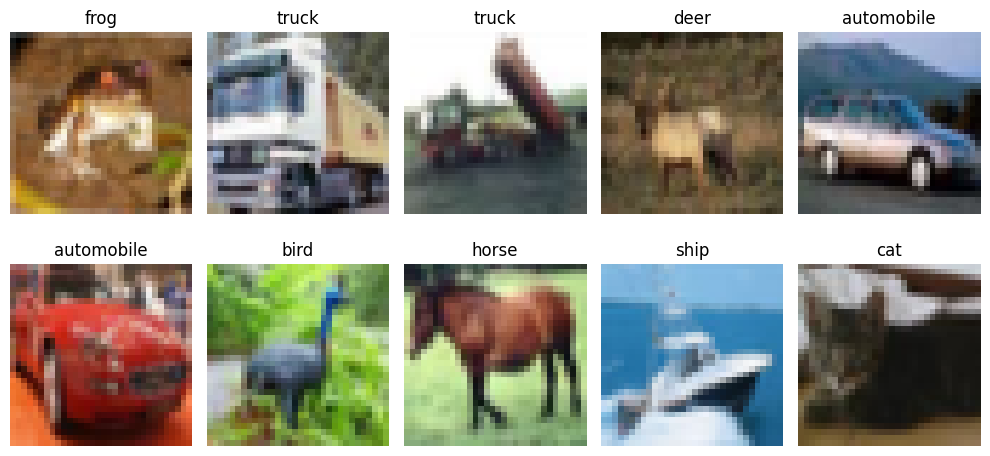

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Preprocessing

Scaling pixels down to 0-1 (helps training converge way faster). Also flattening a
copy for the ANN since dense layers just want a 1D vector, they don't care about
the image being 2D.

In [4]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("CNN input shape:", x_train_norm.shape[1:])
print("ANN input shape:", x_train_flat.shape[1:])

CNN input shape: (32, 32, 3)
ANN input shape: (3072,)


## 4. Small helper to train + log

Writing this once so every model gets evaluated the same way and I don't forget to
save accuracy/loss/params for the comparison table at the end.

In [5]:
def train_and_log(name, model, x_tr, x_te, epochs, batch_size=64, callbacks=None):
    history = model.fit(
        x_tr, y_train,
        epochs=epochs,
        validation_split=0.1,
        batch_size=batch_size,
        callbacks=callbacks or [],
        verbose=2,
    )
    test_loss, test_acc = model.evaluate(x_te, y_test, verbose=0)
    epochs_ran = len(history.history['loss'])

    results[name] = {
        "model": model,
        "history": history,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "params": model.count_params(),
        "epochs": epochs_ran,
        "x_eval": x_te,
    }
    print(f"\n{name} -> test acc: {test_acc:.4f}, test loss: {test_loss:.4f}, "
          f"params: {model.count_params():,}, epochs run: {epochs_ran}")
    return history

## 5. ANN baseline

Just a plain fully connected net. No conv layers, so it has zero idea that nearby
pixels are related to each other — basically treating the image like a long list
of random numbers.

In [6]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax'),
], name="ANN_Baseline")

ann_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

ann_history = train_and_log("ANN (baseline)", ann_model, x_train_flat, x_test_flat, epochs=10)

Epoch 1/10
704/704 - 7s - 10ms/step - accuracy: 0.2729 - loss: 1.9835 - val_accuracy: 0.3142 - val_loss: 1.8682
Epoch 2/10
704/704 - 2s - 3ms/step - accuracy: 0.3124 - loss: 1.8744 - val_accuracy: 0.3534 - val_loss: 1.7915
Epoch 3/10
704/704 - 2s - 3ms/step - accuracy: 0.3362 - loss: 1.8155 - val_accuracy: 0.3854 - val_loss: 1.7487
Epoch 4/10
704/704 - 3s - 4ms/step - accuracy: 0.3496 - loss: 1.7798 - val_accuracy: 0.3908 - val_loss: 1.7389
Epoch 5/10
704/704 - 2s - 3ms/step - accuracy: 0.3622 - loss: 1.7518 - val_accuracy: 0.4092 - val_loss: 1.6958
Epoch 6/10
704/704 - 2s - 3ms/step - accuracy: 0.3682 - loss: 1.7306 - val_accuracy: 0.4190 - val_loss: 1.6856
Epoch 7/10
704/704 - 2s - 3ms/step - accuracy: 0.3762 - loss: 1.7157 - val_accuracy: 0.4130 - val_loss: 1.6614
Epoch 8/10
704/704 - 2s - 3ms/step - accuracy: 0.3803 - loss: 1.6995 - val_accuracy: 0.4316 - val_loss: 1.6422
Epoch 9/10
704/704 - 2s - 3ms/step - accuracy: 0.3807 - loss: 1.6966 - val_accuracy: 0.4284 - val_loss: 1.6549


## 6. CNN baseline

Same 10 epoch budget as the ANN so it's a fair comparison. Conv + batchnorm + maxpool,
three blocks, pretty standard setup.

In [7]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax'),
], name="CNN_Baseline")

cnn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

cnn_history = train_and_log("CNN (baseline)", cnn_model, x_train_norm, x_test_norm, epochs=10)

Epoch 1/10
704/704 - 14s - 19ms/step - accuracy: 0.4710 - loss: 1.4806 - val_accuracy: 0.5830 - val_loss: 1.1708
Epoch 2/10
704/704 - 3s - 4ms/step - accuracy: 0.6116 - loss: 1.1132 - val_accuracy: 0.6114 - val_loss: 1.1906
Epoch 3/10
704/704 - 4s - 5ms/step - accuracy: 0.6710 - loss: 0.9455 - val_accuracy: 0.5748 - val_loss: 1.4317
Epoch 4/10
704/704 - 3s - 4ms/step - accuracy: 0.7162 - loss: 0.8103 - val_accuracy: 0.6644 - val_loss: 0.9686
Epoch 5/10
704/704 - 3s - 4ms/step - accuracy: 0.7422 - loss: 0.7241 - val_accuracy: 0.6788 - val_loss: 0.9946
Epoch 6/10
704/704 - 3s - 4ms/step - accuracy: 0.7722 - loss: 0.6452 - val_accuracy: 0.6958 - val_loss: 0.9017
Epoch 7/10
704/704 - 4s - 5ms/step - accuracy: 0.7949 - loss: 0.5724 - val_accuracy: 0.6724 - val_loss: 1.0635
Epoch 8/10
704/704 - 3s - 4ms/step - accuracy: 0.8164 - loss: 0.5158 - val_accuracy: 0.6964 - val_loss: 0.9926
Epoch 9/10
704/704 - 3s - 4ms/step - accuracy: 0.8319 - loss: 0.4659 - val_accuracy: 0.7136 - val_loss: 0.9164

## 7. ANN vs CNN — same epochs, who wins?

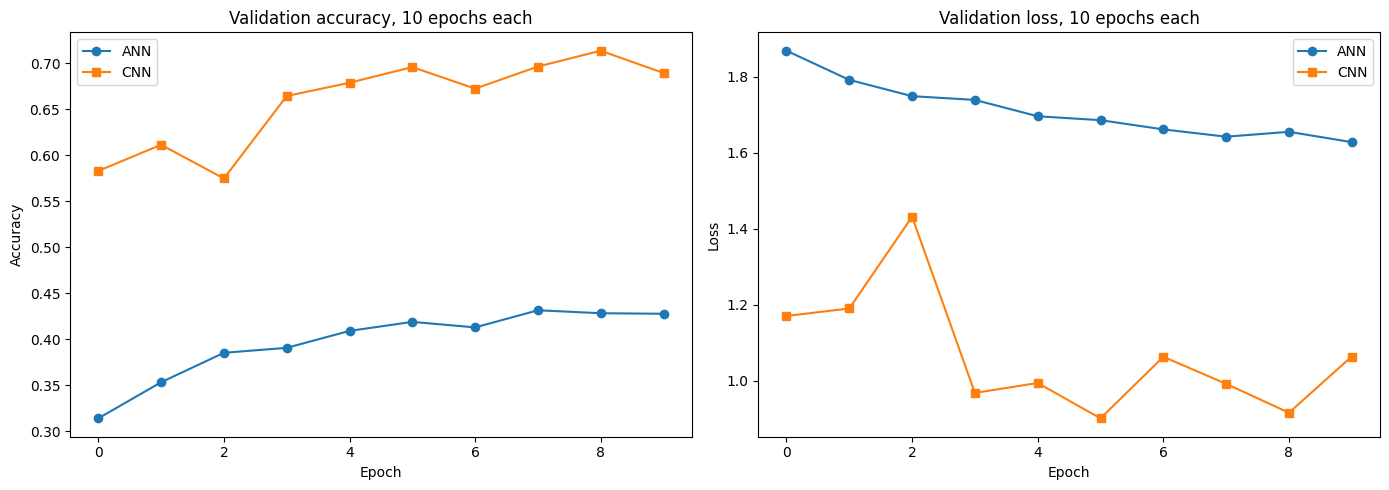

ANN: 42.8% vs CNN: 66.7%, same training budget. Conv layers clearly carrying their weight here.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ann_history.history['val_accuracy'], 'o-', label='ANN')
axes[0].plot(cnn_history.history['val_accuracy'], 's-', label='CNN')
axes[0].set_title("Validation accuracy, 10 epochs each")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(ann_history.history['val_loss'], 'o-', label='ANN')
axes[1].plot(cnn_history.history['val_loss'], 's-', label='CNN')
axes[1].set_title("Validation loss, 10 epochs each")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ANN: {results['ANN (baseline)']['test_acc']:.1%} vs CNN: {results['CNN (baseline)']['test_acc']:.1%}, "
      "same training budget. Conv layers clearly carrying their weight here.")

## 8. Pushing the CNN further

Trying out the stuff that's supposed to actually improve a model instead of just
throwing more layers at it:

1. Deeper ANN, just to see if depth alone helps it catch up to CNN
2. Bigger CNN (more filters, dropout per block)
3. Longer training budget (20 epochs)
4. EarlyStopping so it doesn't keep training once val_loss stops improving
5. Data augmentation

Using a fresh EarlyStopping callback per model so one model's patience counter
doesn't carry over into the next one's training.

In [9]:
EPOCHS = 20

def make_early_stopping():
    return EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print(f"Enhanced models get up to {EPOCHS} epochs, early stopping on val_loss.")

Enhanced models get up to 20 epochs, early stopping on val_loss.


### 8.1 — Deeper ANN

In [10]:
ann_enhanced = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax'),
], name="ANN_Enhanced")

ann_enhanced.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

train_and_log("ANN (enhanced)", ann_enhanced, x_train_flat, x_test_flat,
              epochs=EPOCHS, callbacks=[make_early_stopping()])

Epoch 1/20
704/704 - 10s - 15ms/step - accuracy: 0.3322 - loss: 1.9115 - val_accuracy: 0.3450 - val_loss: 1.8020
Epoch 2/20
704/704 - 3s - 4ms/step - accuracy: 0.3960 - loss: 1.6878 - val_accuracy: 0.3718 - val_loss: 1.7485
Epoch 3/20
704/704 - 3s - 4ms/step - accuracy: 0.4170 - loss: 1.6273 - val_accuracy: 0.4282 - val_loss: 1.6078
Epoch 4/20
704/704 - 3s - 4ms/step - accuracy: 0.4238 - loss: 1.6093 - val_accuracy: 0.3944 - val_loss: 1.6741
Epoch 5/20
704/704 - 3s - 5ms/step - accuracy: 0.4247 - loss: 1.6044 - val_accuracy: 0.4084 - val_loss: 1.6569
Epoch 6/20
704/704 - 5s - 6ms/step - accuracy: 0.4322 - loss: 1.5855 - val_accuracy: 0.4388 - val_loss: 1.5621
Epoch 7/20
704/704 - 3s - 4ms/step - accuracy: 0.4350 - loss: 1.5771 - val_accuracy: 0.4678 - val_loss: 1.4959
Epoch 8/20
704/704 - 3s - 4ms/step - accuracy: 0.4402 - loss: 1.5638 - val_accuracy: 0.4690 - val_loss: 1.4948
Epoch 9/20
704/704 - 3s - 5ms/step - accuracy: 0.4426 - loss: 1.5498 - val_accuracy: 0.4574 - val_loss: 1.5218

### 8.2 — Bigger CNN, dropout after every block

In [11]:
cnn_enhanced = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax'),
], name="CNN_Enhanced")

cnn_enhanced.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

train_and_log("CNN (enhanced)", cnn_enhanced, x_train_norm, x_test_norm,
              epochs=EPOCHS, callbacks=[make_early_stopping()])

Epoch 1/20
704/704 - 19s - 27ms/step - accuracy: 0.4029 - loss: 1.6620 - val_accuracy: 0.4966 - val_loss: 1.5052
Epoch 2/20
704/704 - 4s - 5ms/step - accuracy: 0.5312 - loss: 1.3053 - val_accuracy: 0.5816 - val_loss: 1.1972
Epoch 3/20
704/704 - 4s - 6ms/step - accuracy: 0.5902 - loss: 1.1508 - val_accuracy: 0.5760 - val_loss: 1.1944
Epoch 4/20
704/704 - 4s - 5ms/step - accuracy: 0.6301 - loss: 1.0474 - val_accuracy: 0.6844 - val_loss: 0.8938
Epoch 5/20
704/704 - 4s - 5ms/step - accuracy: 0.6574 - loss: 0.9738 - val_accuracy: 0.7080 - val_loss: 0.8554
Epoch 6/20
704/704 - 4s - 6ms/step - accuracy: 0.6799 - loss: 0.9141 - val_accuracy: 0.6948 - val_loss: 0.9116
Epoch 7/20
704/704 - 4s - 5ms/step - accuracy: 0.6946 - loss: 0.8703 - val_accuracy: 0.6748 - val_loss: 0.9845
Epoch 8/20
704/704 - 5s - 7ms/step - accuracy: 0.7107 - loss: 0.8290 - val_accuracy: 0.6940 - val_loss: 0.9390
Epoch 9/20
704/704 - 4s - 6ms/step - accuracy: 0.7197 - loss: 0.8021 - val_accuracy: 0.7062 - val_loss: 0.9942

### 8.3 — CNN + data augmentation

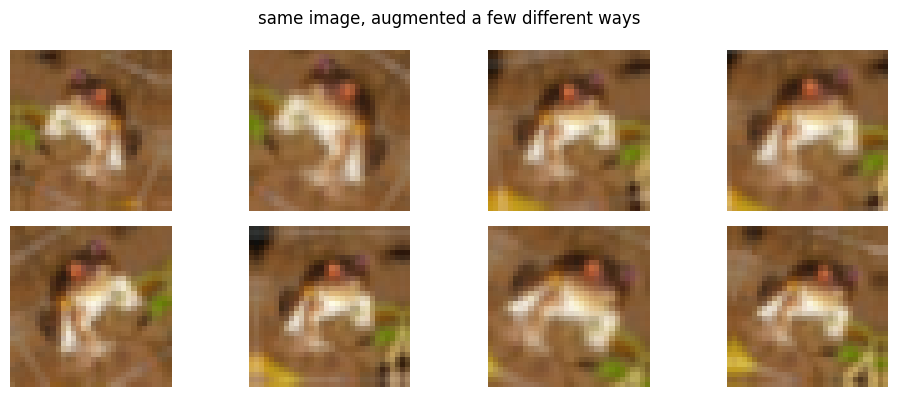

Epoch 1/20
352/352 - 11s - 32ms/step - accuracy: 0.3779 - loss: 1.7303 - val_accuracy: 0.3010 - val_loss: 2.2620
Epoch 2/20
352/352 - 6s - 16ms/step - accuracy: 0.4775 - loss: 1.4591 - val_accuracy: 0.4980 - val_loss: 1.4955
Epoch 3/20
352/352 - 5s - 14ms/step - accuracy: 0.5263 - loss: 1.3238 - val_accuracy: 0.5528 - val_loss: 1.2704
Epoch 4/20
352/352 - 6s - 16ms/step - accuracy: 0.5671 - loss: 1.2313 - val_accuracy: 0.5724 - val_loss: 1.2820
Epoch 5/20
352/352 - 10s - 29ms/step - accuracy: 0.5926 - loss: 1.1580 - val_accuracy: 0.6110 - val_loss: 1.1128
Epoch 6/20
352/352 - 5s - 15ms/step - accuracy: 0.6098 - loss: 1.1075 - val_accuracy: 0.5414 - val_loss: 1.4596
Epoch 7/20
352/352 - 5s - 14ms/step - accuracy: 0.6277 - loss: 1.0628 - val_accuracy: 0.6248 - val_loss: 1.1236
Epoch 8/20
352/352 - 6s - 16ms/step - accuracy: 0.6428 - loss: 1.0256 - val_accuracy: 0.6608 - val_loss: 1.0148
Epoch 9/20
352/352 - 5s - 15ms/step - accuracy: 0.6562 - loss: 0.9908 - val_accuracy: 0.6512 - val_los

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

plt.figure(figsize=(10, 4))
sample = x_train_norm[0:1]
for i in range(8):
    aug_img = data_augmentation(sample, training=True)[0]
    plt.subplot(2, 4, i+1)
    plt.imshow(aug_img)
    plt.axis("off")
plt.suptitle("same image, augmented a few different ways")
plt.tight_layout()
plt.show()

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax'),
], name="CNN_Augmented")

aug_cnn_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

train_and_log("CNN + Augmentation", aug_cnn_model, x_train_norm, x_test_norm,
              epochs=EPOCHS, batch_size=128, callbacks=[make_early_stopping()])

## 9. Best model — closer look

Best model: CNN + Augmentation (test acc 0.7292)


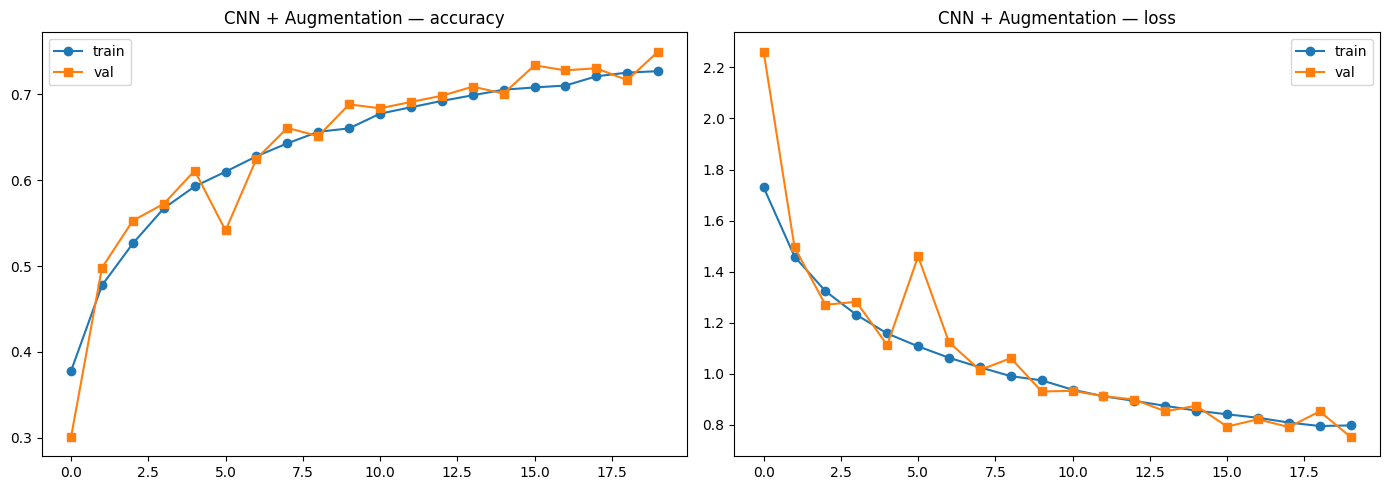

In [13]:
best_name = max(results, key=lambda k: results[k]['test_acc'])
best = results[best_name]
print(f"Best model: {best_name} (test acc {best['test_acc']:.4f})")

h = best['history'].history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h['accuracy'], 'o-', label='train')
axes[0].plot(h['val_accuracy'], 's-', label='val')
axes[0].set_title(f"{best_name} — accuracy"); axes[0].legend()
axes[1].plot(h['loss'], 'o-', label='train')
axes[1].plot(h['val_loss'], 's-', label='val')
axes[1].set_title(f"{best_name} — loss"); axes[1].legend()
plt.tight_layout()
plt.show()

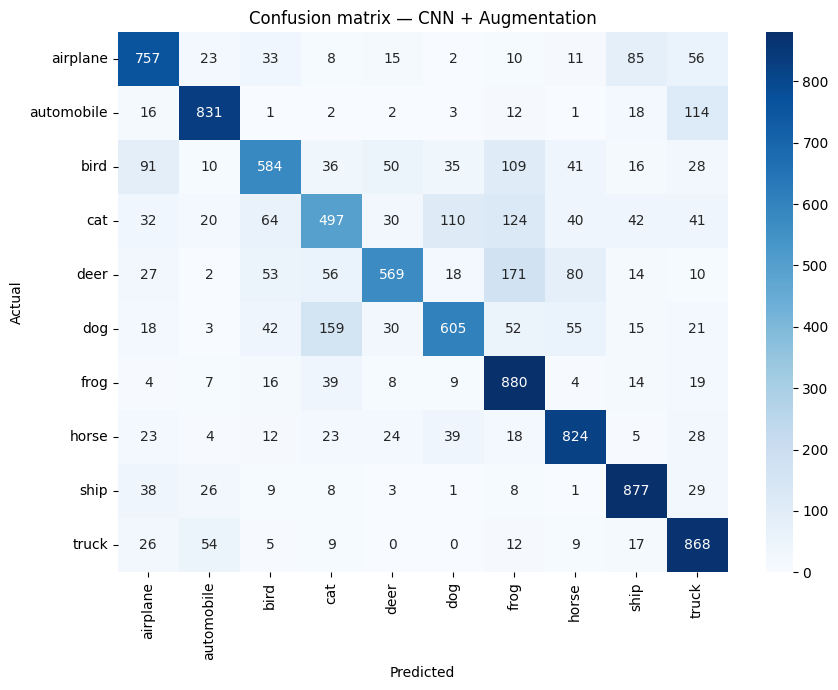

              precision    recall  f1-score   support

    airplane       0.73      0.76      0.75      1000
  automobile       0.85      0.83      0.84      1000
        bird       0.71      0.58      0.64      1000
         cat       0.59      0.50      0.54      1000
        deer       0.78      0.57      0.66      1000
         dog       0.74      0.60      0.66      1000
        frog       0.63      0.88      0.73      1000
       horse       0.77      0.82      0.80      1000
        ship       0.80      0.88      0.83      1000
       truck       0.71      0.87      0.78      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.72     10000
weighted avg       0.73      0.73      0.72     10000



In [14]:
y_true = y_test.flatten()
y_pred = np.argmax(best['model'].predict(best['x_eval'], verbose=0), axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion matrix — {best_name}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

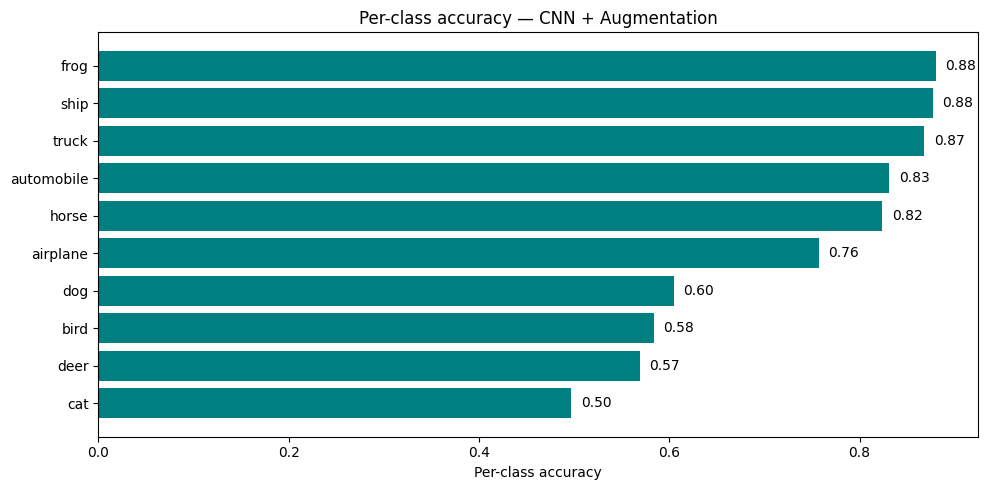

In [15]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
order = np.argsort(per_class_acc)

plt.figure(figsize=(10, 5))
plt.barh([class_names[i] for i in order], per_class_acc[order], color='teal')
for i, v in enumerate(per_class_acc[order]):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center')
plt.xlabel("Per-class accuracy")
plt.title(f"Per-class accuracy — {best_name}")
plt.tight_layout()
plt.show()

### Observations

- CNNs beat the ANN by a clear margin, even the baseline one with the same epoch budget.
- Vehicles (automobile, truck, ship) are the easiest — they have distinct shapes/colors.
- Cat vs dog and deer vs horse are where it messes up the most, makes sense since they
  look pretty similar at 32x32 resolution.
- Batch norm + dropout + augmentation all helped close the gap between train and val
  accuracy, meaning less overfitting.

## 10. Final comparison — all models

In [16]:
comparison = pd.DataFrame([
    {
        "Model": name,
        "Test Accuracy": round(r["test_acc"], 4),
        "Test Loss": round(r["test_loss"], 4),
        "Parameters": r["params"],
        "Epochs Run": r["epochs"],
    }
    for name, r in results.items()
]).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

comparison

,Model,Test Accuracy,Test Loss,Parameters,Epochs Run
0,CNN + Augmentation,0.7292,0.7977,357706,20
1,CNN (enhanced),0.6914,0.8877,621258,10
2,CNN (baseline),0.6673,1.1232,357194,10
3,ANN (enhanced),0.4990,1.4156,3811594,20
4,ANN (baseline),0.4277,1.6116,1707274,10


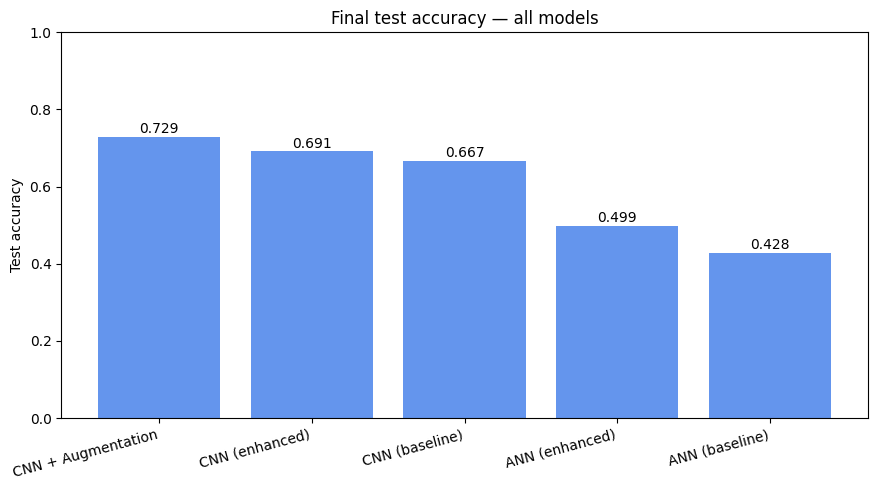

In [17]:
plt.figure(figsize=(9, 5))
bars = plt.bar(comparison["Model"], comparison["Test Accuracy"], color='cornflowerblue')
for b, v in zip(bars, comparison["Test Accuracy"]):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}", ha='center')
plt.ylabel("Test accuracy"); plt.ylim(0, 1)
plt.title("Final test accuracy — all models")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 11. Conclusion

Architecture beats raw training time — the baseline CNN outperformed the baseline ANN with the exact same 10-epoch budget, just because conv layers preserve the image's 2D structure instead of flattening it into a meaningless list of numbers.


Going deeper helped both models a bit, but the bigger jump came from training strategies — batch norm, dropout, and augmentation pushed validation accuracy up while keeping the train/val gap smaller, meaning the model generalizes better instead of just memorizing the training set.


**Overall takeaway**: for image data, CNN beats ANN basically every time, and the extra training tricks are worth it if you've got the time budget for them.
